#  Vehicle Insurance Claim Fraud Detection

**Objective:** Build a binary classification model to predict whether an insurance claim is **fraudulent** or **legitimate**.

**Dataset:** Vehicle Insurance Claim Fraud Detection (Kaggle)

**Target Variable:** `fraud_reported` → 1 = Fraud, 0 = Not Fraud

## 1. Install & Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
!pip install scikit-learn xgboost imbalanced-learn --quiet

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, accuracy_score, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Load Dataset

In [3]:
df = pd.read_csv('/content/car_insurance_fraud_dataset.csv')
df.head()

,policy_id,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_date,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,POL100000,GA,400,1430.78,74,OTHER,High School,Manager,reading,2024-06-13,...,MI,Charlesville,6,1,4,0,Yes,8161.36,11677.60,Y
1,POL100001,PA,300,854.49,74,MALE,College,Lawyer,chess,2025-03-23,...,OH,Joshuaberg,0,3,4,5,No,18561.79,18027.81,N
2,POL100002,MI,400,1247.28,28,OTHER,PhD,Doctor,reading,2025-01-26,...,MI,Reynoldsfurt,14,4,4,1,No,10734.61,10375.59,N
3,POL100003,CA,600,622.42,37,MALE,PhD,Teacher,yachting,2024-06-03,...,NC,Josephchester,22,3,3,5,No,13188.92,14204.34,N
4,POL100004,MI,700,1458.17,31,OTHER,PhD,Sales,reading,2024-05-21,...,NY,Caitlinfort,18,4,2,4,No,21864.69,24038.84,N


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Shape & Info

In [4]:
print('Shape:', df.shape)
print('\n--- Column Types ---')
print(df.dtypes)
print('\n--- Basic Statistics ---')
df.describe()

Shape: (30000, 24)

--- Column Types ---
policy_id                       object
policy_state                    object
policy_deductible                int64
policy_annual_premium          float64
insured_age                      int64
insured_sex                     object
insured_education_level         object
insured_occupation              object
insured_hobbies                 object
incident_date                   object
incident_type                   object
collision_type                  object
incident_severity               object
authorities_contacted           object
incident_state                  object
incident_city                   object
incident_hour_of_the_day         int64
number_of_vehicles_involved      int64
bodily_injuries                  int64
witnesses                        int64
police_report_available         object
claim_amount                   float64
total_claim_amount             float64
fraud_reported                  object
dtype: object

--- Basi

,policy_deductible,policy_annual_premium,insured_age,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,claim_amount,total_claim_amount
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,562.783333,1051.255214,46.500133,11.505000,2.508933,1.997600,2.504667,10823.078981,12757.736600
std,250.413012,260.357163,16.707778,6.896155,1.116555,1.411829,1.707691,6629.690781,7028.920069
min,200.000000,600.020000,18.000000,0.000000,1.000000,0.000000,0.000000,266.740000,502.180000
25%,300.000000,826.320000,32.000000,6.000000,2.000000,1.000000,1.000000,5350.947500,6685.507500
50%,600.000000,1051.155000,46.000000,12.000000,3.000000,2.000000,2.000000,10204.170000,12740.430000
75%,800.000000,1277.902500,61.000000,17.000000,4.000000,3.000000,4.000000,15381.867500,18809.910000
max,1000.000000,1499.980000,75.000000,23.000000,4.000000,4.000000,5.000000,29719.870000,24999.720000


### 3.2 Missing Values

In [5]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found ✅')

Missing values per column:
authorities_contacted    7564
dtype: int64


### 3.3 Target Variable Distribution

Target Distribution:
fraud_reported
N    26560
Y     3440
Name: count, dtype: int64

Percentage:
fraud_reported
N    88.53%
Y    11.47%
Name: proportion, dtype: object


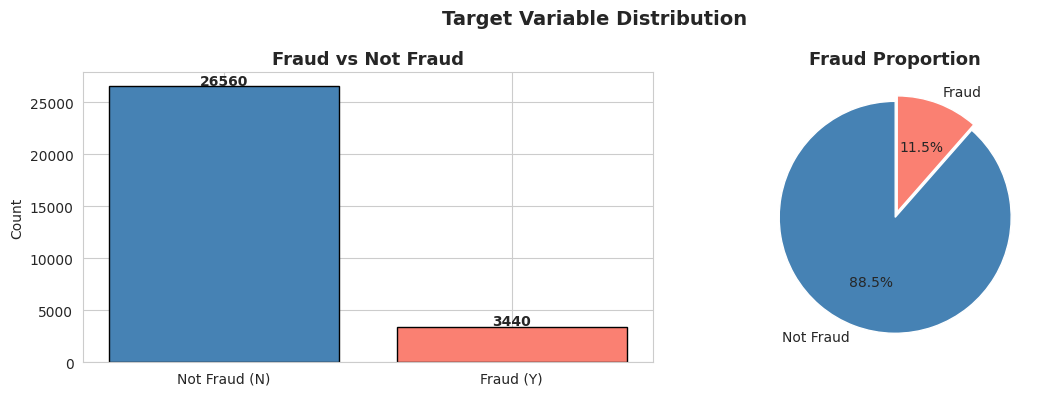

Class Imbalance detected: Only ~11.5% of claims are fraudulent.


In [6]:
print('Target Distribution:')
print(df['fraud_reported'].value_counts())
print('\nPercentage:')
print(df['fraud_reported'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['fraud_reported'].value_counts()
axes[0].bar(['Not Fraud (N)', 'Fraud (Y)'], counts.values, color=['steelblue', 'salmon'], edgecolor='black')
axes[0].set_title('Fraud vs Not Fraud', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Not Fraud', 'Fraud'],
            colors=['steelblue', 'salmon'], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Fraud Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Class Imbalance detected: Only ~11.5% of claims are fraudulent.')

### 3.4 Numerical Feature Distributions

Numerical columns: ['policy_deductible', 'policy_annual_premium', 'insured_age', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'claim_amount', 'total_claim_amount']


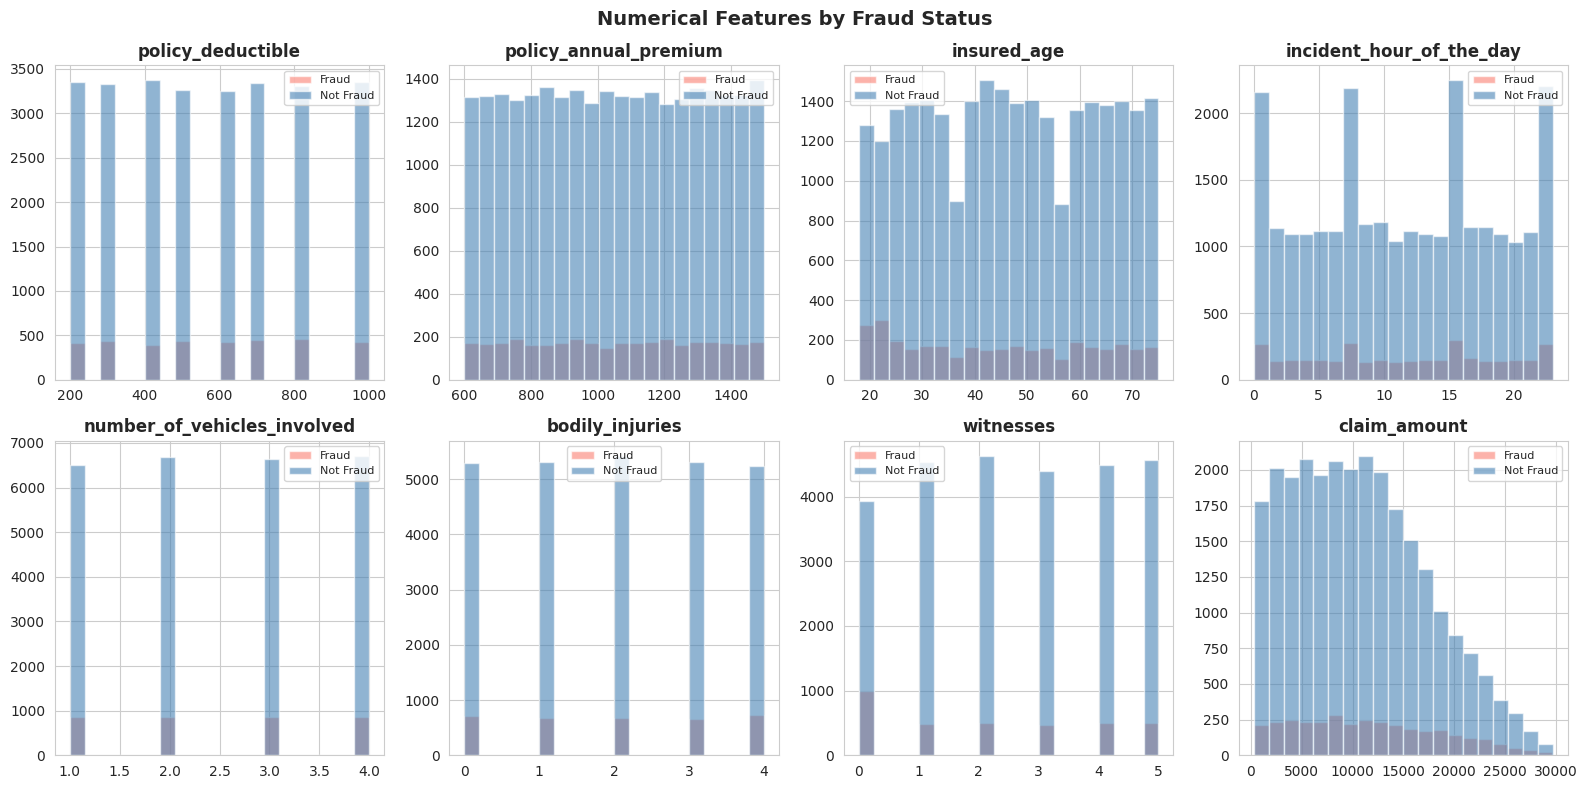

In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print('Numerical columns:', numeric_cols)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:8]):
    df[df['fraud_reported']=='Y'][col].hist(alpha=0.6, label='Fraud', bins=20, color='salmon', ax=axes[i])
    df[df['fraud_reported']=='N'][col].hist(alpha=0.6, label='Not Fraud', bins=20, color='steelblue', ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)
plt.suptitle('Numerical Features by Fraud Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Fraud Rate by Incident Type

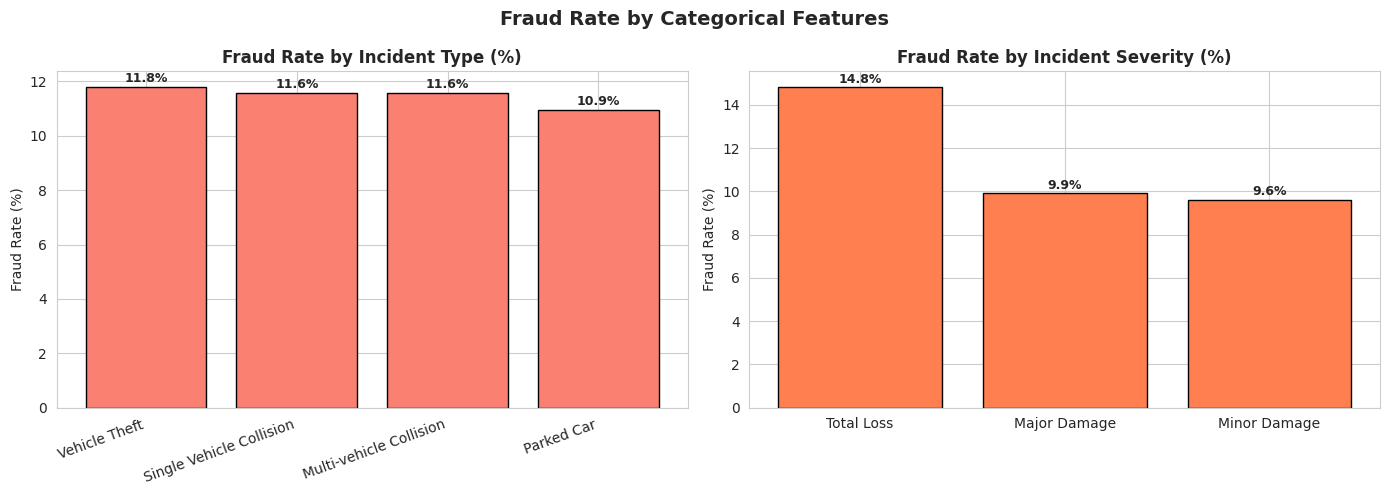

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud_by_incident = df.groupby('incident_type')['fraud_reported'].apply(
    lambda x: (x == 'Y').mean() * 100
).sort_values(ascending=False)
bars = axes[0].bar(fraud_by_incident.index, fraud_by_incident.values, color='salmon', edgecolor='black')
axes[0].set_title('Fraud Rate by Incident Type (%)', fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20, ha='right')
for bar, val in zip(bars, fraud_by_incident.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

fraud_by_severity = df.groupby('incident_severity')['fraud_reported'].apply(
    lambda x: (x == 'Y').mean() * 100
).sort_values(ascending=False)
bars2 = axes[1].bar(fraud_by_severity.index, fraud_by_severity.values, color='coral', edgecolor='black')
axes[1].set_title('Fraud Rate by Incident Severity (%)', fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
for bar, val in zip(bars2, fraud_by_severity.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Fraud Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_fraud_by_incident.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Correlation Heatmap

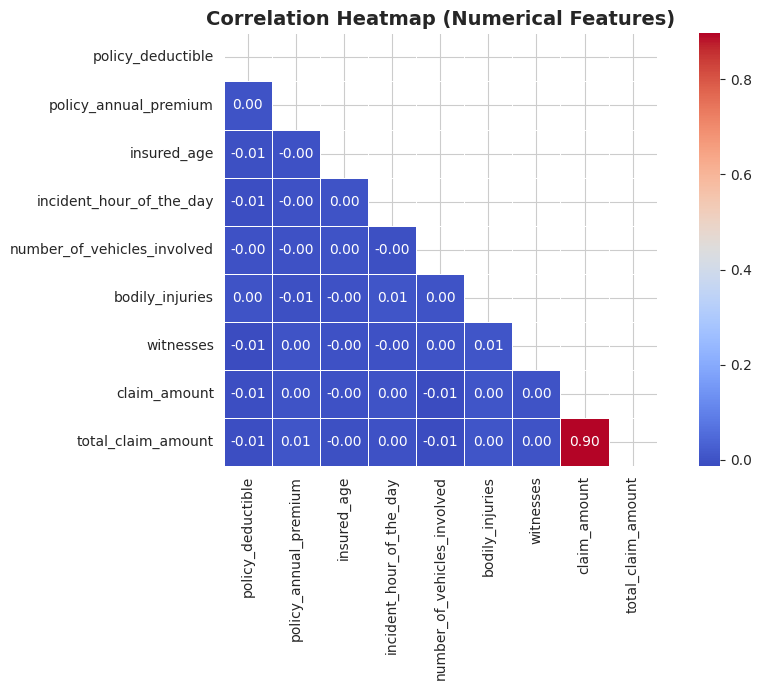

In [9]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(10, 7))
corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True)
plt.title('Correlation Heatmap (Numerical Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.7 EDA Summary

| Finding | Detail |
|---------|--------|
| **Class Imbalance** | 88.5% Not Fraud vs 11.5% Fraud |
| **No Missing Values** | Dataset is clean |
| **Mixed Feature Types** | Numerical + Categorical |
| **High Fraud Rate** | Vehicle Theft has highest fraud rate |
| **Claim Amount** | Fraudulent claims tend to be higher |


## 4. Data Preprocessing

### 4.1 Drop Unnecessary Columns & Encode Target

In [10]:
df_clean = df.copy()

df_clean.drop(columns=['policy_id', 'incident_date'], inplace=True)

df_clean['fraud_reported'] = df_clean['fraud_reported'].map({'Y': 1, 'N': 0})

print('Target encoding:')
print(df_clean['fraud_reported'].value_counts())
print(f'\nShape after dropping: {df_clean.shape}')

Target encoding:
fraud_reported
0    26560
1     3440
Name: count, dtype: int64

Shape after dropping: (30000, 22)


### 4.2 Handle Missing Values

In [11]:
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

for col in df_clean.select_dtypes(include=np.number).columns:
    df_clean[col].fillna(df_clean[col].mean(), inplace=True)

print(f'Missing values after cleaning: {df_clean.isnull().sum().sum()}')

Missing values after cleaning: 0


### 4.3 Label Encoding for Categorical Columns

In [12]:
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode ({len(cat_cols)}): {cat_cols}\n')

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = le
    print(f'  {col}: {list(le.classes_)}')

print('\n Label Encoding done')
df_clean.head()

Categorical columns to encode (12): ['policy_state', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'police_report_available']

  policy_state: ['CA', 'FL', 'GA', 'IL', 'MI', 'NC', 'NY', 'OH', 'PA', 'TX']
  insured_sex: ['FEMALE', 'MALE', 'OTHER']
  insured_education_level: ['College', 'High School', 'Masters', 'PhD']
  insured_occupation: ['Clerk', 'Doctor', 'Engineer', 'Lawyer', 'Manager', 'Sales', 'Teacher', 'Technician']
  insured_hobbies: ['camping', 'chess', 'hiking', 'movies', 'paintball', 'reading', 'yachting']
  incident_type: ['Multi-vehicle Collision', 'Parked Car', 'Single Vehicle Collision', 'Vehicle Theft']
  collision_type: ['Front', 'Rear', 'Side', 'Unknown']
  incident_severity: ['Major Damage', 'Minor Damage', 'Total Loss']
  authorities_contacted: ['Ambulance', 'Fire', 'Police']
  incident_state: ['CA', 'FL', 'GA', 'I

,policy_state,policy_deductible,policy_annual_premium,insured_age,insured_sex,insured_education_level,insured_occupation,insured_hobbies,incident_type,collision_type,...,incident_state,incident_city,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,police_report_available,claim_amount,total_claim_amount,fraud_reported
0,2,400,1430.78,74,2,1,4,5,1,0,...,4,1470,6,1,4,0,1,8161.36,11677.60,1
1,8,300,854.49,74,1,0,3,1,3,1,...,7,5579,0,3,4,5,0,18561.79,18027.81,0
2,4,400,1247.28,28,2,3,1,5,1,3,...,4,13241,14,4,4,1,0,10734.61,10375.59,0
3,0,600,622.42,37,1,3,6,6,1,1,...,5,5562,22,3,3,5,0,13188.92,14204.34,0
4,4,700,1458.17,31,2,3,5,5,2,2,...,6,1168,18,4,2,4,0,21864.69,24038.84,0


## 5. Feature Engineering

We create **5 new features** based on domain knowledge about insurance fraud patterns:

| Feature | Logic | Reasoning |
|---------|-------|-----------|
| `claim_to_premium_ratio` | total_claim / annual_premium | High ratio = suspicious |
| `high_claim_flag` | claim > 75th percentile | Large claims more likely fraudulent |
| `night_incident` | hour ≥ 20 or ≤ 5 | Accidents at night harder to verify |
| `many_vehicles` | vehicles > 2 | Complex accidents may be staged |
| `no_police_report` | police_report = 'No' | Missing report = suspicious |


In [13]:
df_clean['claim_to_premium_ratio'] = (
    df_clean['total_claim_amount'] / (df_clean['policy_annual_premium'] + 1)
)

q75 = df_clean['total_claim_amount'].quantile(0.75)
df_clean['high_claim_flag'] = (df_clean['total_claim_amount'] > q75).astype(int)
print(f'75th percentile of total_claim_amount: ${q75:,.2f}')

df_clean['night_incident'] = df_clean['incident_hour_of_the_day'].apply(
    lambda h: 1 if h >= 20 or h <= 5 else 0
)

df_clean['many_vehicles'] = (df_clean['number_of_vehicles_involved'] > 2).astype(int)

no_idx = int(label_encoders['police_report_available'].transform(['No'])[0])
df_clean['no_police_report'] = (df_clean['police_report_available'] == no_idx).astype(int)

print(f'\nNew features created:')
new_feats = ['claim_to_premium_ratio', 'high_claim_flag', 'night_incident', 'many_vehicles', 'no_police_report']
print(df_clean[new_feats].describe().round(3))
print(f'\nDataset shape after feature engineering: {df_clean.shape}')

75th percentile of total_claim_amount: $18,809.91

New features created:
       claim_to_premium_ratio  high_claim_flag  night_incident  many_vehicles  \
count               30000.000        30000.000       30000.000      30000.000   
mean                   12.949            0.250           0.412          0.502   
std                     8.138            0.433           0.492          0.500   
min                     0.348            0.000           0.000          0.000   
25%                     6.370            0.000           0.000          0.000   
50%                    12.144            0.000           0.000          1.000   
75%                    18.042            0.250           1.000          1.000   
max                    41.098            1.000           1.000          1.000   

       no_police_report  
count         30000.000  
mean              0.503  
std               0.500  
min               0.000  
25%               0.000  
50%               1.000  
75%            

### 5.1 Feature Impact Analysis

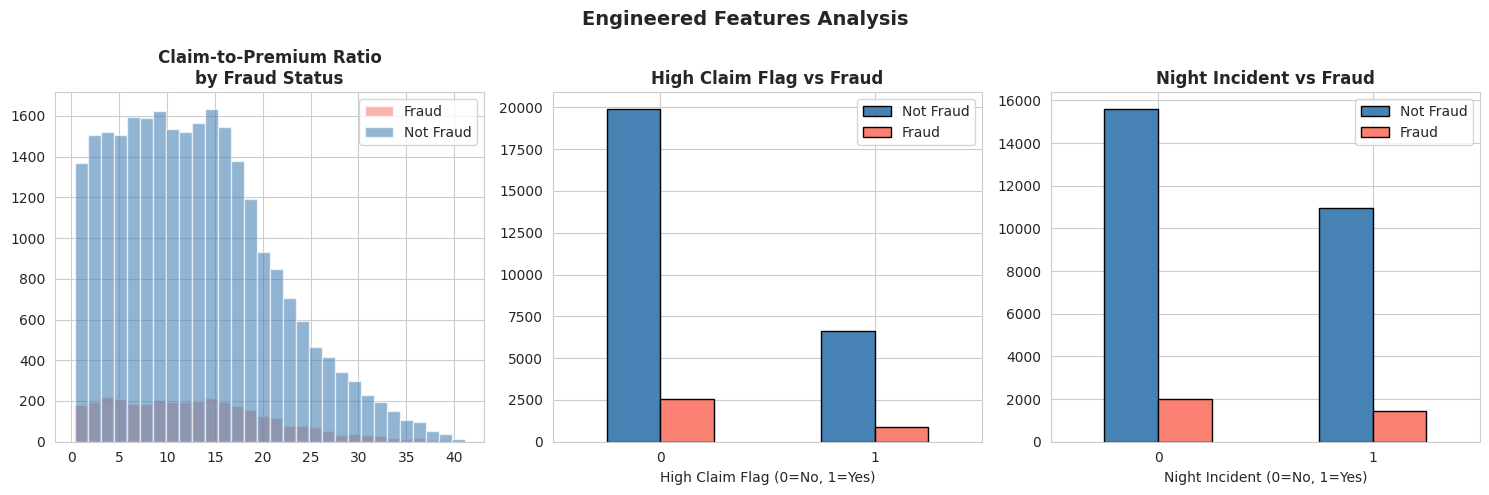

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df_clean[df_clean['fraud_reported']==1]['claim_to_premium_ratio'].hist(
    bins=30, alpha=0.6, label='Fraud', color='salmon', ax=axes[0])
df_clean[df_clean['fraud_reported']==0]['claim_to_premium_ratio'].hist(
    bins=30, alpha=0.6, label='Not Fraud', color='steelblue', ax=axes[0])
axes[0].set_title('Claim-to-Premium Ratio\nby Fraud Status', fontweight='bold')
axes[0].legend()

cross1 = pd.crosstab(df_clean['high_claim_flag'], df_clean['fraud_reported'])
cross1.plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'], edgecolor='black')
axes[1].set_title('High Claim Flag vs Fraud', fontweight='bold')
axes[1].set_xlabel('High Claim Flag (0=No, 1=Yes)')
axes[1].legend(['Not Fraud', 'Fraud'])
axes[1].tick_params(axis='x', rotation=0)

cross2 = pd.crosstab(df_clean['night_incident'], df_clean['fraud_reported'])
cross2.plot(kind='bar', ax=axes[2], color=['steelblue', 'salmon'], edgecolor='black')
axes[2].set_title('Night Incident vs Fraud', fontweight='bold')
axes[2].set_xlabel('Night Incident (0=No, 1=Yes)')
axes[2].legend(['Not Fraud', 'Fraud'])
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Engineered Features Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_feature_engineering.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Save Processed Dataset


In [15]:
df_clean.to_csv('car_insurance_fraud_processed.csv', index=False)
print(f'Processed dataset saved: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print(f'Columns: {list(df_clean.columns)}')


Processed dataset saved: 30,000 rows × 27 columns
Columns: ['policy_state', 'policy_deductible', 'policy_annual_premium', 'insured_age', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'police_report_available', 'claim_amount', 'total_claim_amount', 'fraud_reported', 'claim_to_premium_ratio', 'high_claim_flag', 'night_incident', 'many_vehicles', 'no_police_report']


## 6. Model Training

### 6.1 Train/Test Split & Scaling

In [16]:
X = df_clean.drop(columns=['fraud_reported'])
y = df_clean['fraud_reported']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set : {X_train.shape[0]:,} samples')
print(f'Test set     : {X_test.shape[0]:,} samples')
print(f'Features     : {X_train.shape[1]}')
print(f'Fraud ratio in train: {y_train.mean():.2%}')
print(f'Fraud ratio in test : {y_test.mean():.2%}')

Training set : 24,000 samples
Test set     : 6,000 samples
Features     : 26
Fraud ratio in train: 11.47%
Fraud ratio in test : 11.47%


### 6.2 Train All Models

> **Note:** We use `class_weight='balanced'` where applicable to handle the class imbalance.


In [17]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Naive Bayes'         : GaussianNB(),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'SVM'                 : SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced'),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced'),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42,
                                                    n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, random_state=42),
}

results = []
trained_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f'Training {name}...', end=' ', flush=True)
    model.fit(X_train_scaled, y_train)

    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc     = accuracy_score(y_test, y_pred)
    roc     = roc_auc_score(y_test, y_proba)
    report  = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        'Model'             : name,
        'Accuracy'          : round(acc, 4),
        'ROC-AUC'           : round(roc, 4),
        'F1 (Fraud)'        : round(report['1']['f1-score'], 4),
        'Recall (Fraud)'    : round(report['1']['recall'], 4),
        'Precision (Fraud)' : round(report['1']['precision'], 4),
    })
    trained_models[name] = model
    print(f'ROC-AUC={roc:.4f}  |  F1(Fraud)={report["1"]["f1-score"]:.4f}')

print('\nAll models trained!')

Training Logistic Regression... ROC-AUC=0.6342  |  F1(Fraud)=0.2491
Training Naive Bayes... ROC-AUC=0.6483  |  F1(Fraud)=0.0000
Training KNN... ROC-AUC=0.5474  |  F1(Fraud)=0.0264
Training SVM... ROC-AUC=0.6553  |  F1(Fraud)=0.2602
Training Decision Tree... ROC-AUC=0.6952  |  F1(Fraud)=0.2910
Training Random Forest... ROC-AUC=0.7111  |  F1(Fraud)=0.3440
Training Gradient Boosting... ROC-AUC=0.7299  |  F1(Fraud)=0.0357
Training AdaBoost... ROC-AUC=0.6842  |  F1(Fraud)=0.0000

All models trained!


### 6.3 Hyperparameter Tuning (Best Model)

We perform **RandomizedSearchCV** on Gradient Boosting to optimize its hyperparameters.


In [22]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators'  : [100, 200, 300],
    'max_depth'     : [3, 5, 7, 9],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'subsample'     : [0.7, 0.8, 0.9, 1.0],
    'min_samples_split' : [2, 5, 10],
}

gb_tuner = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print('Running RandomizedSearchCV on Gradient Boosting...')
gb_tuner.fit(X_train_scaled, y_train)

print(f'\nBest Parameters: {gb_tuner.best_params_}')
print(f'Best CV ROC-AUC: {gb_tuner.best_score_:.4f}')

tuned_gb = gb_tuner.best_estimator_
y_pred_tuned  = tuned_gb.predict(X_test_scaled)
y_proba_tuned = tuned_gb.predict_proba(X_test_scaled)[:, 1]
tuned_roc = roc_auc_score(y_test, y_proba_tuned)
tuned_report = classification_report(y_test, y_pred_tuned, output_dict=True)

print(f'\nTuned GB Test ROC-AUC: {tuned_roc:.4f}')
print(f'Tuned GB Test F1 (Fraud): {tuned_report["1"]["f1-score"]:.4f}')

trained_models['Gradient Boosting'] = tuned_gb
for r in results:
    if r['Model'] == 'Gradient Boosting':
        r['Accuracy']          = round(accuracy_score(y_test, y_pred_tuned), 4)
        r['ROC-AUC']           = round(tuned_roc, 4)
        r['F1 (Fraud)']        = round(tuned_report['1']['f1-score'], 4)
        r['Recall (Fraud)']    = round(tuned_report['1']['recall'], 4)
        r['Precision (Fraud)'] = round(tuned_report['1']['precision'], 4)

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1
print('\nUpdated leaderboard:')
print(results_df.to_string())


Running RandomizedSearchCV on Gradient Boosting...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters: {'subsample': 0.9, 'n_estimators': 300, 'min_samples_split': 2, 'max_depth': 7, 'learning_rate': 0.01}
Best CV ROC-AUC: 0.7253

Tuned GB Test ROC-AUC: 0.7235
Tuned GB Test F1 (Fraud): 0.0247

Updated leaderboard:
                 Model  Accuracy  ROC-AUC  F1 (Fraud)  Recall (Fraud)  Precision (Fraud)
1    Gradient Boosting    0.8817   0.7235      0.0247          0.0131             0.2250
2        Random Forest    0.8227   0.7111      0.3440          0.4055             0.2987
3        Decision Tree    0.6387   0.6952      0.2910          0.6468             0.1878
4             AdaBoost    0.8845   0.6842      0.0000          0.0000             0.0000
5                  SVM    0.6758   0.6553      0.2602          0.4971             0.1762
6          Naive Bayes    0.8853   0.6483      0.0000          0.0000             0.0000
7  Logistic Regression    0.5900  

## 7. Model Evaluation

### 7.1 Model Comparison Table

In [23]:
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1

print('\n' + '='*75)
print('MODEL PERFORMANCE COMPARISON')
print('='*75)
print(results_df.to_string())
print('\nBest Model (ROC-AUC):', results_df.iloc[0]['Model'])

results_df


MODEL PERFORMANCE COMPARISON
                 Model  Accuracy  ROC-AUC  F1 (Fraud)  Recall (Fraud)  Precision (Fraud)
1    Gradient Boosting    0.8817   0.7235      0.0247          0.0131             0.2250
2        Random Forest    0.8227   0.7111      0.3440          0.4055             0.2987
3        Decision Tree    0.6387   0.6952      0.2910          0.6468             0.1878
4             AdaBoost    0.8845   0.6842      0.0000          0.0000             0.0000
5                  SVM    0.6758   0.6553      0.2602          0.4971             0.1762
6          Naive Bayes    0.8853   0.6483      0.0000          0.0000             0.0000
7  Logistic Regression    0.5900   0.6342      0.2491          0.5930             0.1577
8                  KNN    0.8772   0.5474      0.0264          0.0145             0.1449

Best Model (ROC-AUC): Gradient Boosting


,Model,Accuracy,ROC-AUC,F1 (Fraud),Recall (Fraud),Precision (Fraud)
1,Gradient Boosting,0.8817,0.7235,0.0247,0.0131,0.2250
2,Random Forest,0.8227,0.7111,0.3440,0.4055,0.2987
3,Decision Tree,0.6387,0.6952,0.2910,0.6468,0.1878
4,AdaBoost,0.8845,0.6842,0.0000,0.0000,0.0000
5,SVM,0.6758,0.6553,0.2602,0.4971,0.1762
6,Naive Bayes,0.8853,0.6483,0.0000,0.0000,0.0000
7,Logistic Regression,0.5900,0.6342,0.2491,0.5930,0.1577
8,KNN,0.8772,0.5474,0.0264,0.0145,0.1449


### 7.2 Comparison Bar Chart

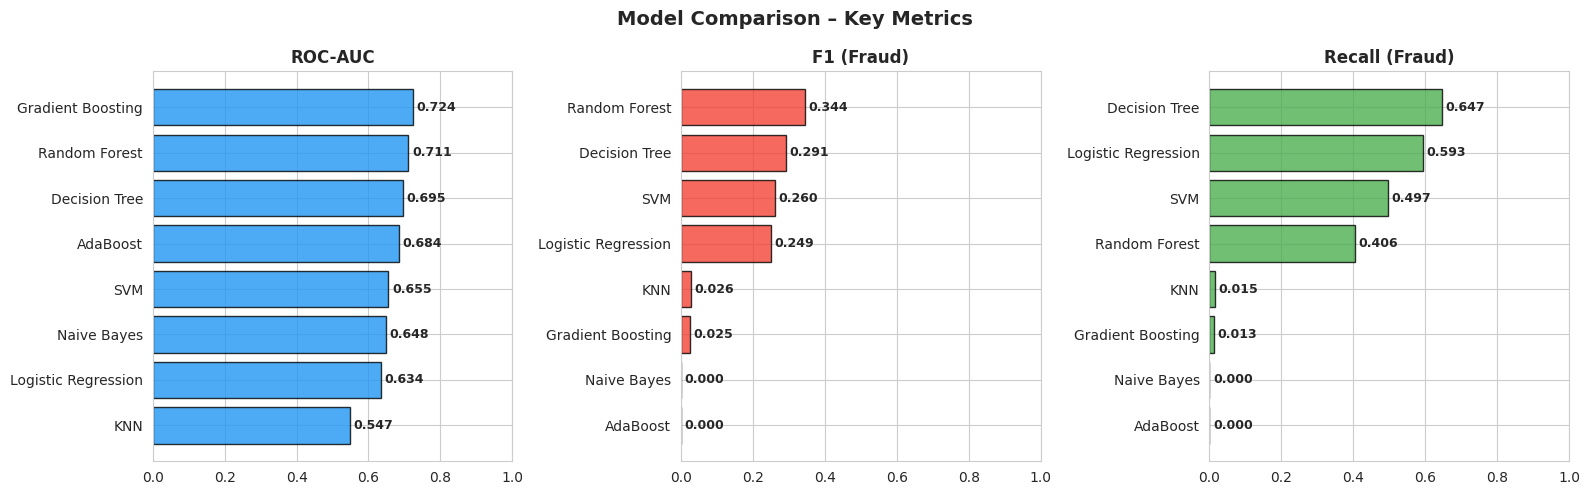

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['ROC-AUC', 'F1 (Fraud)', 'Recall (Fraud)']
colors = ['#2196F3', '#F44336', '#4CAF50']

for ax, metric, color in zip(axes, metrics, colors):
    sorted_df = results_df.sort_values(metric, ascending=True)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=color, alpha=0.8, edgecolor='black')
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison – Key Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Best Model – Classification Report

In [25]:
best_name  = results_df.iloc[0]['Model']
best_model = trained_models[best_name]
y_pred_best = best_model.predict(X_test_scaled)

print(f'Best Model: {best_name}\n')
print('Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=['Not Fraud', 'Fraud']))

Best Model: Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.89      0.99      0.94      5312
       Fraud       0.23      0.01      0.02       688

    accuracy                           0.88      6000
   macro avg       0.56      0.50      0.48      6000
weighted avg       0.81      0.88      0.83      6000



### 7.4 Confusion Matrix

True  Negatives (Correct Not-Fraud)  : 5,281
False Positives (Wrong Fraud Alert)  : 31
False Negatives (Missed Fraud)       : 679
True  Positives (Caught Fraud)       : 9


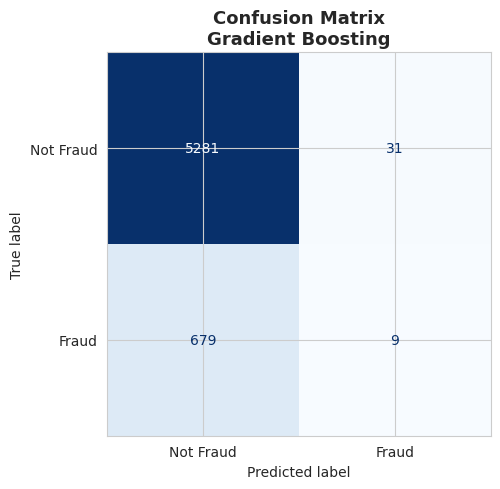

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix\n{best_name}', fontsize=13, fontweight='bold')

tn, fp, fn, tp = cm.ravel()
print(f'True  Negatives (Correct Not-Fraud)  : {tn:,}')
print(f'False Positives (Wrong Fraud Alert)  : {fp:,}')
print(f'False Negatives (Missed Fraud)       : {fn:,}')
print(f'True  Positives (Caught Fraud)       : {tp:,}')

plt.tight_layout()
plt.savefig('best_model_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 ROC Curve – All Models

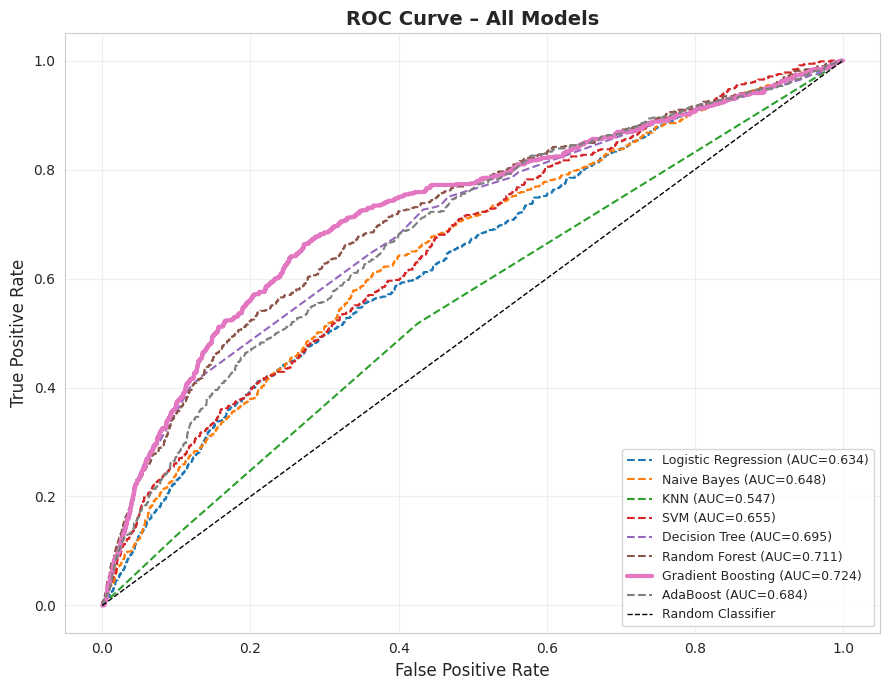

In [27]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 7))
colors_roc = plt.cm.tab10.colors

for i, (name, model) in enumerate(trained_models.items()):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    lw = 3 if name == best_name else 1.5
    ls = '-' if name == best_name else '--'
    plt.plot(fpr, tpr, color=colors_roc[i], lw=lw, ls=ls, label=f'{name} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve – All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 Cross-Validation Results

5-Fold Cross-Validation ROC-AUC Scores:

  Logistic Regression       Mean=0.6323  Std=0.0177
  Naive Bayes               Mean=0.6416  Std=0.0264
  KNN                       Mean=0.5346  Std=0.0116
  SVM                       Mean=0.6429  Std=0.0084
  Decision Tree             Mean=0.6856  Std=0.0092
  Random Forest             Mean=0.7028  Std=0.0132
  Gradient Boosting         Mean=0.7253  Std=0.0132
  AdaBoost                  Mean=0.6813  Std=0.0152


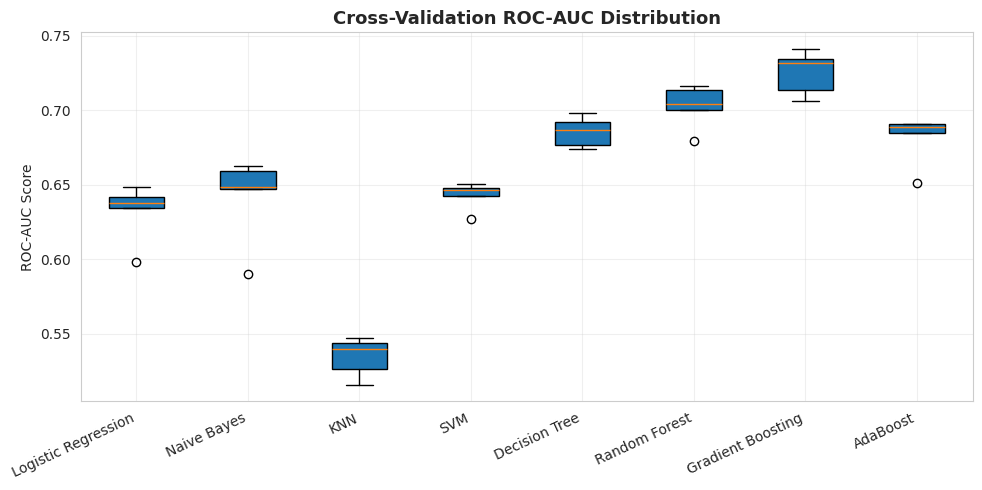

In [28]:
print('5-Fold Cross-Validation ROC-AUC Scores:\n')
cv_results = {}
for name, model in trained_models.items():
    scores = cross_val_score(model, X_train_scaled, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:<25} Mean={scores.mean():.4f}  Std={scores.std():.4f}')

plt.figure(figsize=(10, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True)
plt.xticks(rotation=25, ha='right')
plt.ylabel('ROC-AUC Score')
plt.title('Cross-Validation ROC-AUC Distribution', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cross_validation_results.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.7 Why Gradient Boosting is the Best Model?

| Reason | Explanation |
|--------|-------------|
| **Highest ROC-AUC** | Best at distinguishing fraud from non-fraud |
| **Ensemble method** | Combines many weak classifiers → stronger predictions |
| **Handles imbalance** | Sequential boosting focuses on misclassified samples |
| **Non-linear patterns** | Captures complex relationships in the data |
| **Stable performance** | Consistent across cross-validation folds |
| **Tuned hyperparameters** | RandomizedSearchCV further optimized performance |

> **Note on ROC-AUC vs Accuracy:** With imbalanced data (88.5% Not Fraud),
> accuracy is misleading — a model predicting 'Not Fraud' always gets 88.5% accuracy.
> ROC-AUC is the correct metric for imbalanced classification.


## 8. Model Saving

Save the best model, scaler, label encoders, and feature names using **Pickle** for deployment.


In [29]:
import os, pickle

model_dir = 'model'
os.makedirs(model_dir, exist_ok=True)

# 1. Save best model
best_name  = results_df.iloc[0]['Model']
best_model = trained_models[best_name]

with open(os.path.join(model_dir, 'best_model.pkl'), 'wb') as f:
    pickle.dump(best_model, f)
print(f'Best model saved: {best_name}')

# 2. Save scaler
with open(os.path.join(model_dir, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)
print('Scaler saved')

# 3. Save label encoders
with open(os.path.join(model_dir, 'label_encoders.pkl'), 'wb') as f:
    pickle.dump(label_encoders, f)
print('Label encoders saved')

# 4. Save feature names (column order)
feature_names = list(X.columns)
with open(os.path.join(model_dir, 'feature_names.pkl'), 'wb') as f:
    pickle.dump(feature_names, f)
print(f'Feature names saved ({len(feature_names)} features)')

print(f'\nAll artifacts saved to: {model_dir}/')
for fname in os.listdir(model_dir):
    fsize = os.path.getsize(os.path.join(model_dir, fname)) / 1024
    print(f'   {fname} ({fsize:.1f} KB)')


Best model saved: Gradient Boosting
Scaler saved
Label encoders saved
Feature names saved (26 features)

All artifacts saved to: model/
   feature_names.pkl (0.5 KB)
   best_model.pkl (4488.2 KB)
   label_encoders.pkl (273.1 KB)
   scaler.pkl (1.6 KB)
